# PHÂN TÍCH PHÂN CỤM KHÁCH HÀNG (ONLINE RETAIL)

## Mục tiêu phân tích
Mục tiêu của bài toán là phân khúc khách hàng dựa trên hành vi mua sắm lịch sử. Chúng ta sử dụng tập dữ liệu giao dịch **Online Retail** để xây dựng mô hình **RFM (Recency, Frequency, Monetary)**, sau đó áp dụng thuật toán **Phân cụm đa cấp (Hierarchical Clustering)** để nhóm các khách hàng có đặc điểm tương đồng.

Kết quả phân cụm sẽ giúp doanh nghiệp đưa ra các chiến lược marketing phù hợp cho từng nhóm đối tượng (ví dụ: Chăm sóc VIP, Giữ chân khách hàng, v.v.).

### 1. Nhập thư viện

In [2]:
# Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Cấu hình hiển thị
sns.set(style="whitegrid")
%matplotlib inline

### Nhập dữ liệu và xem xét tổng quan về dữ liệu

In [3]:
# 1. Tải dữ liệu
# Lưu ý: File OnlineRetail thường dùng encoding 'ISO-8859-1'
try:
    df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')
except:
    df = pd.read_csv('OnlineRetail.csv', encoding='unicode_escape')

# 2. Tổng quan dữ liệu
print("--- 5 dòng đầu tiên ---")
display(df.head())

print("\n--- Thông tin bộ dữ liệu ---")
print(df.info())

# 3. Kiểm tra dữ liệu thiếu (Missing Values)
print("\n--- Số lượng giá trị thiếu ---")
missing = df.isnull().sum()
print(missing[missing > 0])



--- 5 dòng đầu tiên ---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom



--- Thông tin bộ dữ liệu ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None

--- Số lượng giá trị thiếu ---
Description      1454
CustomerID     135080
dtype: int64


### Thống kê mô tả dữ liệu

`Quantity` và `UnitPrice` đều có giá trị số, có thể đưa vào thống kê mô tả

In [4]:
# 4. Thống kê mô tả cho các biến số
# Chú ý quan sát giá trị âm (trả hàng) hoặc giá trị 0
print("\n--- Thống kê mô tả (Quantity & UnitPrice) ---")
display(df[['Quantity', 'UnitPrice']].describe())


--- Thống kê mô tả (Quantity & UnitPrice) ---


,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


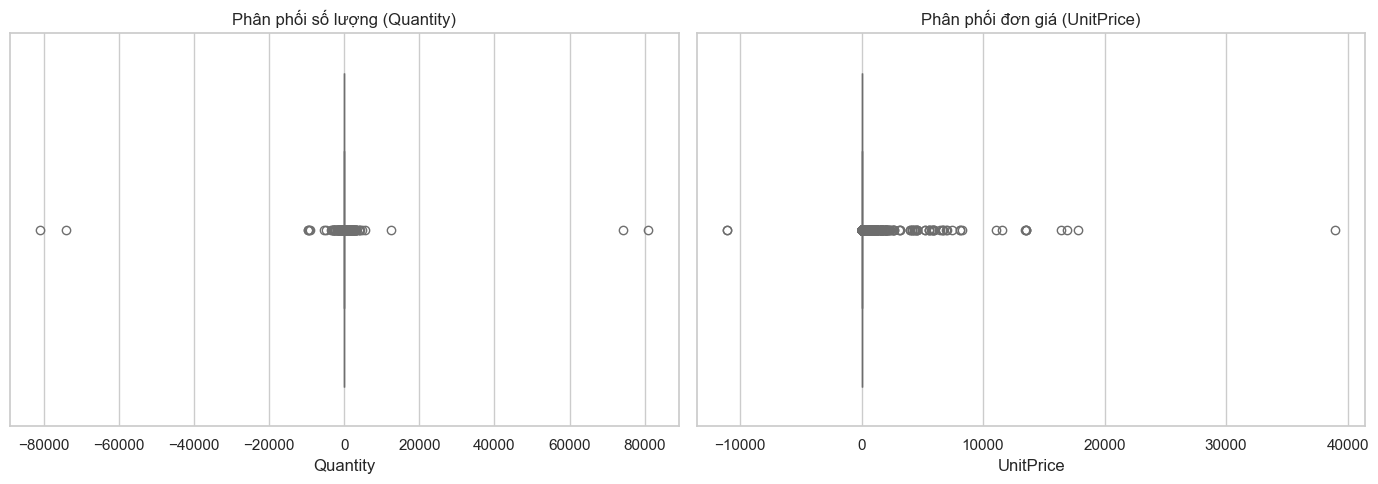

In [5]:
# 5. Trực quan hóa phân phối & Outliers
plt.figure(figsize=(14, 5))

# Biểu đồ Boxplot cho Quantity
plt.subplot(1, 2, 1)
sns.boxplot(x=df['Quantity'], color='skyblue')
plt.title('Phân phối số lượng (Quantity)')
# Biểu đồ Boxplot cho UnitPrice
plt.subplot(1, 2, 2)
sns.boxplot(x=df['UnitPrice'], color='salmon')
plt.title('Phân phối đơn giá (UnitPrice)')

plt.tight_layout()
plt.show()


Có thể thấy có rất nhiều Outlier trong cả 2 thuộc tính do giá cả, số lượng mua có thể tăng lên và hạ xuống do biến động thị trường.

In [6]:
# 6. Kiểm tra số lượng khách hàng và quốc gia
print(f"\nTổng số giao dịch: {df.shape[0]}")
print(f"Số lượng khách hàng duy nhất (Unique CustomerID): {df['CustomerID'].nunique()}")
print(f"Số lượng quốc gia: {df['Country'].nunique()}")


Tổng số giao dịch: 541909
Số lượng khách hàng duy nhất (Unique CustomerID): 4372
Số lượng quốc gia: 38


Có rất nhiều giao dịch và chỉ có 4372 khách hàng là duy nhất hay đến mua 1, lần cho thấy các khu vực có lượng hàng trung và đông đảo.

## 2. Tiền xử lý dữ liệu (Data Preprocessing)

Trước khi đưa vào mô hình, dữ liệu giao dịch thô cần được làm sạch và chuyển đổi:

1.  **Xử lý dữ liệu thiếu:** Loại bỏ các giao dịch không có `CustomerID` vì mục tiêu là phân tích cấp độ khách hàng.
2.  **Làm sạch nhiễu:** Loại bỏ các đơn hàng bị hủy (Quantity < 0) và giá trị lỗi (UnitPrice < 0).
3.  **Xử lý định dạng thời gian:** Chuyển đổi cột `InvoiceDate` sang dạng datetime chuẩn. **Lưu ý:** Dữ liệu gốc có định dạng ngày trước tháng (`dayfirst=True`), cần xử lý đúng để tránh lỗi parse ngày (ví dụ: 13/12 bị hiểu nhầm thành tháng 13).
4.  **Tính toán giá trị đơn hàng:** Tạo cột `TotalAmount` = `Quantity` * `UnitPrice`.

In [7]:
import pandas as pd
import datetime as dt
from sklearn.preprocessing import StandardScaler

# 1. Làm sạch dữ liệu cơ bản
# Loại bỏ dòng không có CustomerID
df_clean = df.dropna(subset=['CustomerID'])
# Loại bỏ đơn hàng trả lại (Quantity < 0) và giá < 0
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# Tính tổng tiền cho mỗi dòng (TotalAmount)
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Chuyển đổi InvoiceDate sang dạng datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'],dayfirst=True)

print(f"Dữ liệu sạch sau khi lọc: {df_clean.shape}")


Dữ liệu sạch sau khi lọc: (397884, 9)


## 3. Xây dựng đặc trưng RFM

Để phân cụm khách hàng, chúng ta không thể sử dụng từng dòng giao dịch lẻ tẻ. Chúng ta cần tổng hợp dữ liệu theo từng khách hàng dựa trên 3 chỉ số vàng trong bán lẻ (**RFM**):

* **Recency (R):** Số ngày tính từ lần mua cuối cùng đến hiện tại. (R càng thấp càng tốt).
* **Frequency (F):** Tổng số lần mua hàng (số hóa đơn duy nhất). (F càng cao càng tốt).
* **Monetary (M):** Tổng số tiền khách hàng đã chi tiêu. (M càng cao càng tốt).

**Xử lý ngoại lai (Outliers):** Dữ liệu bán lẻ thường bị lệch (skewed) do có một số ít khách mua sỉ cực lớn. Chúng ta sử dụng phương pháp **IQR (Interquartile Range)** để lọc bỏ các điểm dữ liệu quá dị biệt, giúp mô hình phân cụm hoạt động ổn định hơn trên nhóm khách hàng phổ thông.

In [8]:

# Tính toán RFM
# Chọn mốc thời gian 'hiện tại' là 1 ngày sau ngày mua cuối cùng trong dữ liệu
snapshot_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

# Group theo CustomerID để tính R, F, M
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency: Số ngày trôi qua
    'InvoiceNo': 'nunique',                                  # Frequency: Số lượng đơn hàng duy nhất
    'TotalAmount': 'sum'                                     # Monetary: Tổng tiền
})

# Đổi tên cột cho dễ hiểu
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalAmount': 'Monetary'
}, inplace=True)

print("\n--- Bảng RFM của 5 khách hàng đầu tiên ---")
display(rfm.head())



--- Bảng RFM của 5 khách hàng đầu tiên ---


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [9]:

# 3. Xử lý ngoại lai (Outliers Treatment)
# Dữ liệu bán lẻ thường bị lệch (skewed). Ta loại bỏ các điểm dữ liệu quá xa (ngoài khoảng 1.5 IQR)
# để thuật toán phân cụm hoạt động ổn định hơn.
Q1 = rfm.quantile(0.05)
Q3 = rfm.quantile(0.95)
IQR = Q3 - Q1
rfm_filtered = rfm[~((rfm < (Q1 - 1.5 * IQR)) | (rfm > (Q3 + 1.5 * IQR))).any(axis=1)]

print(f"\nSố lượng khách hàng trước khi lọc ngoại lai: {rfm.shape[0]}")
print(f"Số lượng khách hàng sau khi lọc ngoại lai: {rfm_filtered.shape[0]}")

# 4. Chuẩn hóa dữ liệu (Standard Scaling)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_filtered)

# Tạo DataFrame hoàn chỉnh để đưa vào mô hình
rfm_normalized = pd.DataFrame(rfm_scaled, columns=rfm.columns, index=rfm_filtered.index)

print("\n--- Dữ liệu RFM đã chuẩn hóa (Sẵn sàng cho phân cụm) ---")
display(rfm_normalized.head().round(2))


Số lượng khách hàng trước khi lọc ngoại lai: 4338
Số lượng khách hàng sau khi lọc ngoại lai: 4263

--- Dữ liệu RFM đã chuẩn hóa (Sẵn sàng cho phân cụm) ---


,Recency,Frequency,Monetary
CustomerID,,,
12347.0,-0.92,0.86,1.64
12348.0,-0.19,0.09,0.26
12349.0,-0.75,-0.68,0.24
12350.0,2.16,-0.68,-0.55
12352.0,-0.58,1.11,0.65


## 4. Đánh giá Mô hình và Insight Khách hàng

Dựa trên kết quả phân cụm đa cấp (Hierarchical Clustering) với phương pháp liên kết Ward và số cụm $k=3$, chúng ta thu được các nhóm khách hàng với đặc điểm trung bình như sau:

| Cụm (Cluster) | Recency (Ngày) | Frequency (Lần) | Monetary ($) | Nhãn (Label) | Số lượng |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Cluster 0** | ~26 ngày | ~8.4 lần | ~$3,360 | **Khách hàng VIP / Trung thành** | ~1,143 |
| **Cluster 1** | ~65 ngày | ~2.1 lần | ~$635 | **Khách hàng Phổ thông / Mới** | ~2,314 |
| **Cluster 2** | ~274 ngày | ~1.4 lần | ~$432 | **Khách hàng Ngủ đông / Rời bỏ** | ~806 |

### Phân tích chi tiết & Khuyến nghị hành động:

* **Nhóm VIP (Cluster 0):**
    * **Đặc điểm:** Mua hàng rất gần đây, tần suất cao và chi tiêu lớn nhất. Đây là nhóm đóng góp doanh thu chủ lực.
    * **Hành động:** Cần chăm sóc đặc biệt, cung cấp dịch vụ ưu tiên, chương trình khách hàng thân thiết (Loyalty Program) để duy trì lòng trung thành.

* **Nhóm Phổ thông (Cluster 1):**
    * **Đặc điểm:** Chiếm số lượng đông đảo nhất (hơn 50%). Mua hàng mức độ trung bình và giá trị giỏ hàng chưa cao.
    * **Hành động:** Tiềm năng để khai thác (Upsell/Cross-sell). Nên gửi các mã giảm giá, gợi ý sản phẩm liên quan để kích thích họ mua nhiều hơn và thường xuyên hơn.

* **Nhóm Ngủ đông (Cluster 2):**
    * **Đặc điểm:** Đã rất lâu (gần 9 tháng) không quay lại mua hàng, chi tiêu thấp. Nguy cơ rời bỏ rất cao.
    * **Hành động:** Thực hiện chiến dịch "Win-back" (gửi email nhắc nhở, ưu đãi cực lớn khi quay lại) hoặc chấp nhận loại bỏ khỏi danh sách marketing tích cực để tiết kiệm chi phí.

In [14]:
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# --- 1. Thử nghiệm so sánh các phương pháp Linkage ---
linkage_methods = ['ward', 'average', 'complete', 'single']
print(f"Đang so sánh hiệu quả các phương pháp với k=3...")
print("-" * 50)
print(f"{'Method':<15} | {'Silhouette Score':<20}")
print("-" * 50)

results = {}
for method in linkage_methods:
    # Huấn luyện mô hình với từng method
    hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage=method)
    labels = hc.fit_predict(rfm_normalized)
    
    # Tính điểm Silhouette
    score = silhouette_score(rfm_normalized, labels)
    results[method] = score
    print(f"{method:<15} | {score:.4f}")

# Chọn phương pháp tốt nhất
best_method = max(results, key=results.get)
print("-" * 50)
print(f"Phương pháp tối ưu nhất: {best_method.upper()} (Score: {results[best_method]:.4f})")

Đang so sánh hiệu quả các phương pháp với k=3...
--------------------------------------------------
Method          | Silhouette Score    
--------------------------------------------------
ward            | 0.4424
average         | 0.6718
complete        | 0.5844
single          | 0.5493
--------------------------------------------------
Phương pháp tối ưu nhất: AVERAGE (Score: 0.6718)


Đang tính toán Dendrogram (có thể mất vài giây)...


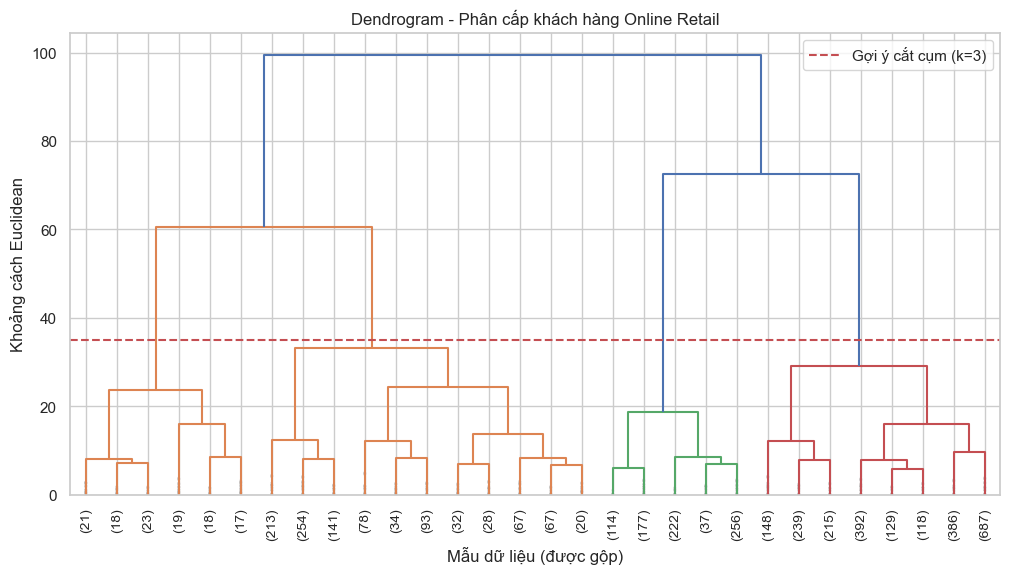

In [15]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# --- 1. Vẽ Dendrogram để xác định số cụm tối ưu ---
# 'ward' là phương pháp liên kết phổ biến giúp tối thiểu hóa phương sai trong cụm
print("Đang tính toán Dendrogram (có thể mất vài giây)...")
Z = linkage(rfm_normalized, method='ward')

plt.figure(figsize=(12, 6))
plt.title("Dendrogram - Phân cấp khách hàng Online Retail")
plt.xlabel("Mẫu dữ liệu (được gộp)")
plt.ylabel("Khoảng cách Euclidean")

# truncate_mode='lastp' giúp biểu đồ gọn hơn, chỉ hiện 30 nhánh cuối cùng
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., show_contracted=True)
plt.axhline(y=35, color='r', linestyle='--', label='Gợi ý cắt cụm (k=3)')
plt.legend()
plt.show()


In [16]:

# --- 2. Xây dựng mô hình Phân cụm Đa cấp (Agglomerative Clustering) ---
k = 3
print(f"Tiến hành phân cụm với số nhóm k = {k}")

hc_model = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
cluster_labels = hc_model.fit_predict(rfm_normalized)

# Gán nhãn cụm vào dữ liệu gốc (đã lọc ngoại lai) để phân tích
rfm_final = rfm_filtered.copy()
rfm_final['Cluster_Label'] = cluster_labels

# --- 3. Phân tích kết quả (Cluster Profiling) ---
print("\n--- Đặc điểm trung bình của từng nhóm khách hàng (Profile) ---")
print(rfm_final.groupby('Cluster_Label').mean().round(2))

print("\n--- Số lượng khách hàng trong mỗi nhóm ---")
print(rfm_final['Cluster_Label'].value_counts())

Tiến hành phân cụm với số nhóm k = 3

--- Đặc điểm trung bình của từng nhóm khách hàng (Profile) ---
               Recency  Frequency  Monetary
Cluster_Label                              
0                25.85       8.37   3359.93
1                64.63       2.08    635.46
2               273.73       1.43    431.98

--- Số lượng khách hàng trong mỗi nhóm ---
Cluster_Label
1    2314
0    1143
2     806
Name: count, dtype: int64


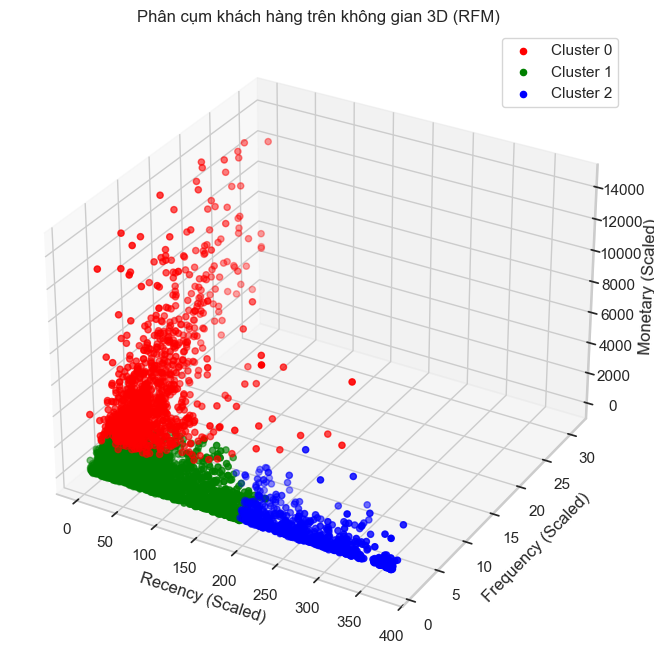

In [17]:

# --- 4. Trực quan hóa 3D (Recency - Frequency - Monetary) ---
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Vẽ từng cụm với màu khác nhau
colors = ['red', 'green', 'blue']
labels = ['Nhóm 0', 'Nhóm 1', 'Nhóm 2']

for i in range(k):
    # Lấy dữ liệu đã chuẩn hóa của cụm i để vẽ (để các trục có cùng tỉ lệ)
    idx = rfm_final.index[cluster_labels == i]
    points = rfm_final.loc[idx]
    
    ax.scatter(points['Recency'], points['Frequency'], points['Monetary'], 
               s=20, c=colors[i], label=f'Cluster {i}')

ax.set_xlabel('Recency (Scaled)')
ax.set_ylabel('Frequency (Scaled)')
ax.set_zlabel('Monetary (Scaled)')
plt.title('Phân cụm khách hàng trên không gian 3D (RFM)')
plt.legend()
plt.show()

--- Bắt đầu chạy K-Means với k=3 ---
K-Means Silhouette Score: 0.5120
--------------------------------------------------
SO SÁNH HIỆU QUẢ (Silhouette Score):
Hierarchical Clustering : 0.4424
K-Means:                        0.5120
=> K-Means hoạt động tốt hơn trên tập dữ liệu này.
--------------------------------------------------


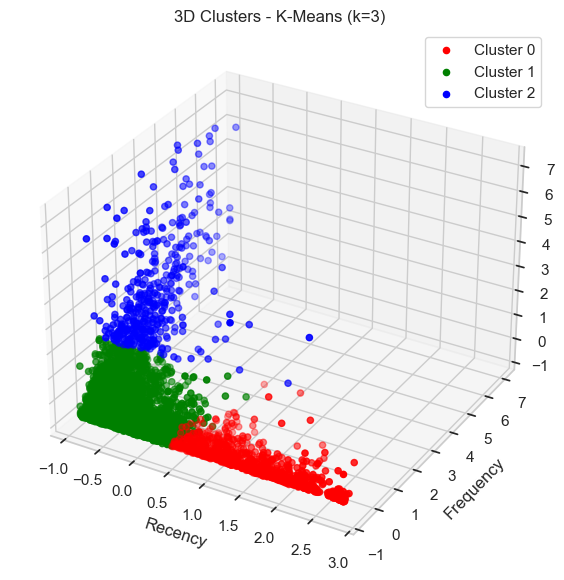

In [19]:
from sklearn.cluster import KMeans

# 1. Cấu hình và huấn luyện K-Means
print("--- Bắt đầu chạy K-Means với k=3 ---")
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, max_iter=300, random_state=42)
kmeans_labels = kmeans.fit_predict(rfm_normalized)

# 2. Đánh giá K-Means
kmeans_score = silhouette_score(rfm_normalized, kmeans_labels)
print(f"K-Means Silhouette Score: {kmeans_score:.4f}")

# 3. So sánh với kết quả tốt nhất của Hierarchical Clustering 
hc_best_score = silhouette_score(rfm_normalized, cluster_labels)
print("-" * 50)
print(f"SO SÁNH HIỆU QUẢ (Silhouette Score):")
print(f"Hierarchical Clustering : {hc_best_score:.4f}")
print(f"K-Means:                        {kmeans_score:.4f}")

if kmeans_score > hc_best_score:
    print("=> K-Means hoạt động tốt hơn trên tập dữ liệu này.")
else:
    print("=> Hierarchical Clustering hoạt động tốt hơn trên tập dữ liệu này.")
print("-" * 50)

# 4. Trực quan hóa kết quả K-Means (3D Plot)
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Gán màu
colors = ['red', 'green', 'blue']
# Lấy dữ liệu gốc để vẽ (hoặc dữ liệu normalized)
points = rfm_normalized.copy()
points['label'] = kmeans_labels

for i in range(3):
    cluster_data = points[points['label'] == i]
    ax.scatter(cluster_data['Recency'], cluster_data['Frequency'], cluster_data['Monetary'],
               s=20, c=colors[i], label=f'Cluster {i}')

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
plt.title("3D Clusters - K-Means (k=3)")
plt.legend()
plt.show()

## 5. Kết luận

Quy trình khai phá dữ liệu từ bước tiền xử lý, làm sạch dữ liệu nhiễu (ngày tháng, đơn hàng hủy) đến việc xây dựng mô hình RFM và áp dụng thuật toán phân cụm đa cấp đã hoàn thành.

Mô hình đã chứng minh tính hiệu quả khi phân tách được khách hàng thành 3 nhóm rõ rệt về mặt hành vi. Biểu đồ Dendrogram và biểu đồ 3D cũng hỗ trợ trực quan hóa sự tách biệt này. Kết quả này cung cấp cơ sở dữ liệu quan trọng để bộ phận Marketing xây dựng chiến lược tiếp cận cá nhân hóa (Personalized Marketing), thay vì áp dụng một chính sách chung cho tất cả khách hàng.

## 6. Lưu kết quả xây dựng mô hình

In [ ]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D

# Tạo thư mục gốc để chứa tất cả kết quả
base_folder = "Experiment_OnlineRetail"
if not os.path.exists(base_folder):
    os.makedirs(base_folder)

def run_and_save_experiment(linkage_method, n_clusters, data_norm, data_original):
    """
    Hàm chạy mô hình, đánh giá và lưu toàn bộ kết quả ra file.
    
    Args:
        linkage_method (str): Phương pháp liên kết ('ward', 'complete', 'average', 'single').
        n_clusters (int): Số lượng cụm.
        data_norm (DataFrame): Dữ liệu đã chuẩn hóa (để training).
        data_original (DataFrame): Dữ liệu gốc (để tính mean profile).
    """
    
    # 1. Tên thư mục con cho thí nghiệm này
    exp_name = f"Method_{linkage_method}_k{n_clusters}"
    exp_dir = os.path.join(base_folder, exp_name)
    if not os.path.exists(exp_dir):
        os.makedirs(exp_dir)
        
    print(f"--- Đang chạy thí nghiệm: {exp_name} ---")
    
    # 2. Xây dựng mô hình
    model = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage=linkage_method)
    labels = model.fit_predict(data_norm)
    
    # Gán nhãn vào dữ liệu gốc để phân tích
    df_analysis = data_original.copy()
    df_analysis['Cluster_Label'] = labels
    
    # 3. Tính toán các chỉ số đánh giá
    sil_score = silhouette_score(data_norm, labels)
    cluster_counts = df_analysis['Cluster_Label'].value_counts().sort_index()
    cluster_means = df_analysis.groupby('Cluster_Label').mean().round(2)
    
    # 4. LƯU BÁO CÁO (TEXT REPORT)
    report_path = os.path.join(exp_dir, "report_stats.txt")
    with open(report_path, "w", encoding="utf-8") as f:
        f.write(f"THÍ NGHIỆM PHÂN CỤM KHÁCH HÀNG (RFM)\n")
        f.write(f"====================================\n")
        f.write(f"Tham số mô hình:\n")
        f.write(f"- Linkage Method: {linkage_method}\n")
        f.write(f"- Số cụm (k): {n_clusters}\n")
        f.write(f"------------------------------------\n")
        f.write(f"KẾT QUẢ ĐÁNH GIÁ:\n")
        f.write(f"- Silhouette Score: {sil_score:.4f}\n\n")
        f.write(f"SỐ LƯỢNG KHÁCH HÀNG MỖI CỤM:\n")
        f.write(f"{cluster_counts.to_string()}\n\n")
        f.write(f"ĐẶC ĐIỂM TRUNG BÌNH (CLUSTER PROFILING):\n")
        f.write(f"{cluster_means.to_string()}\n")
    
    # Lưu bảng Mean ra CSV riêng để dễ dùng Excel xem
    cluster_means.to_csv(os.path.join(exp_dir, "cluster_means.csv"))
    
    print(f"-> Đã lưu báo cáo text và CSV.")

    # 5. LƯU HÌNH ẢNH 1: DENDROGRAM
    # Lưu ý: 'ward' linkage dùng trong dendrogram chỉ hợp lý nếu method='ward'. 
    # Nếu dùng method khác, ta nên vẽ dendrogram tương ứng để nhất quán.
    plt.figure(figsize=(10, 6))
    Z = linkage(data_norm, method=linkage_method)
    dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., show_contracted=True)
    plt.title(f"Dendrogram ({linkage_method})")
    plt.xlabel("Cluster Size")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.savefig(os.path.join(exp_dir, "dendrogram.png"))
    plt.close() # Đóng plot để giải phóng bộ nhớ
    
    # 6. LƯU HÌNH ẢNH 2: 3D SCATTER PLOT
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k'] # Danh sách màu dự phòng
    
    for i in range(n_clusters):
        # Lấy dữ liệu đã scale để vẽ
        points = data_norm[labels == i]
        # Chọn màu an toàn
        color = colors[i % len(colors)]
        ax.scatter(points['Recency'], points['Frequency'], points['Monetary'], 
                   s=20, c=color, label=f'Cluster {i}')
        
    ax.set_xlabel('Recency')
    ax.set_ylabel('Frequency')
    ax.set_zlabel('Monetary')
    plt.title(f"3D Clusters - {linkage_method} (k={n_clusters})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(exp_dir, "3d_scatter_plot.png"))
    plt.close()
    
    print(f"-> Đã lưu hình ảnh Dendrogram và 3D Plot.")
    print(f"-> Hoàn tất thí nghiệm: {exp_name}\n")

# --- CHẠY THỰC NGHIỆM HÀNG LOẠT ---

# Bạn có thể thêm các phương pháp khác vào list này
methods_to_test = ['ward', 'average', 'complete'] 
k_value = 3

for method in methods_to_test:
    # Gọi hàm (đảm bảo bạn đã có biến rfm_normalized và rfm_filtered từ các bước trước)
    run_and_save_experiment(
        linkage_method=method, 
        n_clusters=k_value, 
        data_norm=rfm_normalized, 
        data_original=rfm_filtered
    )

--- Đang chạy thí nghiệm: Method_ward_k3 ---
-> Đã lưu báo cáo text và CSV.
-> Đã lưu hình ảnh Dendrogram và 3D Plot.
-> Hoàn tất thí nghiệm: Method_ward_k3

--- Đang chạy thí nghiệm: Method_average_k3 ---
-> Đã lưu báo cáo text và CSV.
-> Đã lưu hình ảnh Dendrogram và 3D Plot.
-> Hoàn tất thí nghiệm: Method_average_k3

--- Đang chạy thí nghiệm: Method_complete_k3 ---
-> Đã lưu báo cáo text và CSV.
-> Đã lưu hình ảnh Dendrogram và 3D Plot.
-> Hoàn tất thí nghiệm: Method_complete_k3

